## **Dataset:** Obesity Levels

Prediction of Obesity Levels Based On Eating Habits and Physical Activites

Classification of the data using the values of Insufficient Weight, Normal Weight, Overweight Level I or II, Obesity Type I, II or III.

77% of the data was generated synthetically using the Weka tool and the SMOTE filter, 23% of the data was collected directly from users through a web platform.

In [1]:
%pip install numpy pandas matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## Downloading data

In [5]:
dst = "./ObesityDataSet_raw_and_data_sinthetic.csv"
df = pd.read_csv(dst)

In [6]:
df.shape

(2111, 17)

In [7]:
print("All columns:", ", ".join(df.columns.tolist()))

All columns: Age, Gender, Height, Weight, CALC, FAVC, FCVC, NCP, SCC, SMOKE, CH2O, family_history_with_overweight, FAF, TUE, CAEC, MTRANS, NObeyesdad


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Age                             2111 non-null   float64
 1   Gender                          2111 non-null   str    
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   CALC                            2111 non-null   str    
 5   FAVC                            2111 non-null   str    
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   SCC                             2111 non-null   str    
 9   SMOKE                           2111 non-null   str    
 10  CH2O                            2111 non-null   float64
 11  family_history_with_overweight  2111 non-null   str    
 12  FAF                             2111 non-null

## EDA

In [8]:
df.head()

,Age,Gender,Height,Weight,CALC,FAVC,FCVC,NCP,SCC,SMOKE,CH2O,family_history_with_overweight,FAF,TUE,CAEC,MTRANS,NObeyesdad
0,21.0,Female,1.62,64.0,no,no,2.0,3.0,no,no,2.0,yes,0.0,1.0,Sometimes,Public_Transportation,Normal_Weight
1,21.0,Female,1.52,56.0,Sometimes,no,3.0,3.0,yes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,23.0,Male,1.80,77.0,Frequently,no,2.0,3.0,no,no,2.0,yes,2.0,1.0,Sometimes,Public_Transportation,Normal_Weight
3,27.0,Male,1.80,87.0,Frequently,no,3.0,3.0,no,no,2.0,no,2.0,0.0,Sometimes,Walking,Overweight_Level_I
4,22.0,Male,1.78,89.8,Sometimes,no,2.0,1.0,no,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


Analyzing data, precisely looking for outliers

In [9]:
df.describe().round(2)

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.00,2111.00,2111.00,2111.00,2111.00,2111.00,2111.00,2111.00
mean,24.31,1.70,86.59,2.42,2.69,2.01,1.01,0.66
std,6.35,0.09,26.19,0.53,0.78,0.61,0.85,0.61
min,14.00,1.45,39.00,1.00,1.00,1.00,0.00,0.00
25%,19.95,1.63,65.47,2.00,2.66,1.58,0.12,0.00
50%,22.78,1.70,83.00,2.39,3.00,2.00,1.00,0.63
75%,26.00,1.77,107.43,3.00,3.00,2.48,1.67,1.00
max,61.00,1.98,173.00,3.00,4.00,3.00,3.00,2.00


In [10]:
df.isnull().sum()

Age                               0
Gender                            0
Height                            0
Weight                            0
CALC                              0
FAVC                              0
FCVC                              0
NCP                               0
SCC                               0
SMOKE                             0
CH2O                              0
family_history_with_overweight    0
FAF                               0
TUE                               0
CAEC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64

Place to change data.

### Распределение классов (целевая переменная $Y$)

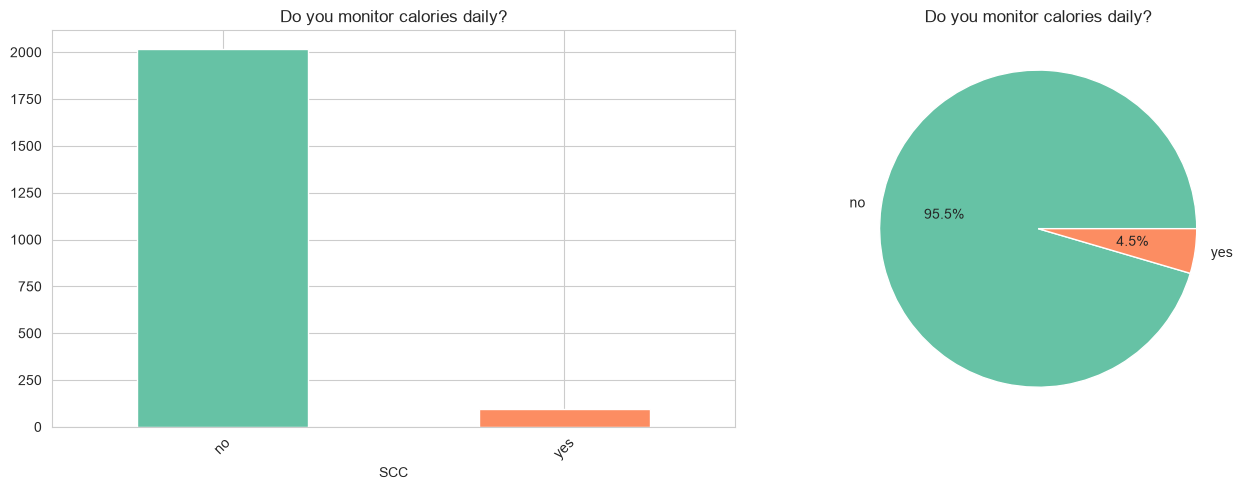

In [18]:
target_col = "SCC"
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df[target_col].value_counts().plot.bar(ax=axes[0], color=sns.color_palette("Set2"))
axes[0].set_title("Do you monitor calories daily?")
axes[0].tick_params(axis="x", rotation=45)

df[target_col].value_counts(normalize=True).plot.pie(ax=axes[1], autopct="%1.1f%%", colors=sns.color_palette("Set2"))
axes[1].set_ylabel("")
axes[1].set_title("Do you monitor calories daily?")
plt.tight_layout()
plt.show()

### Target distribution

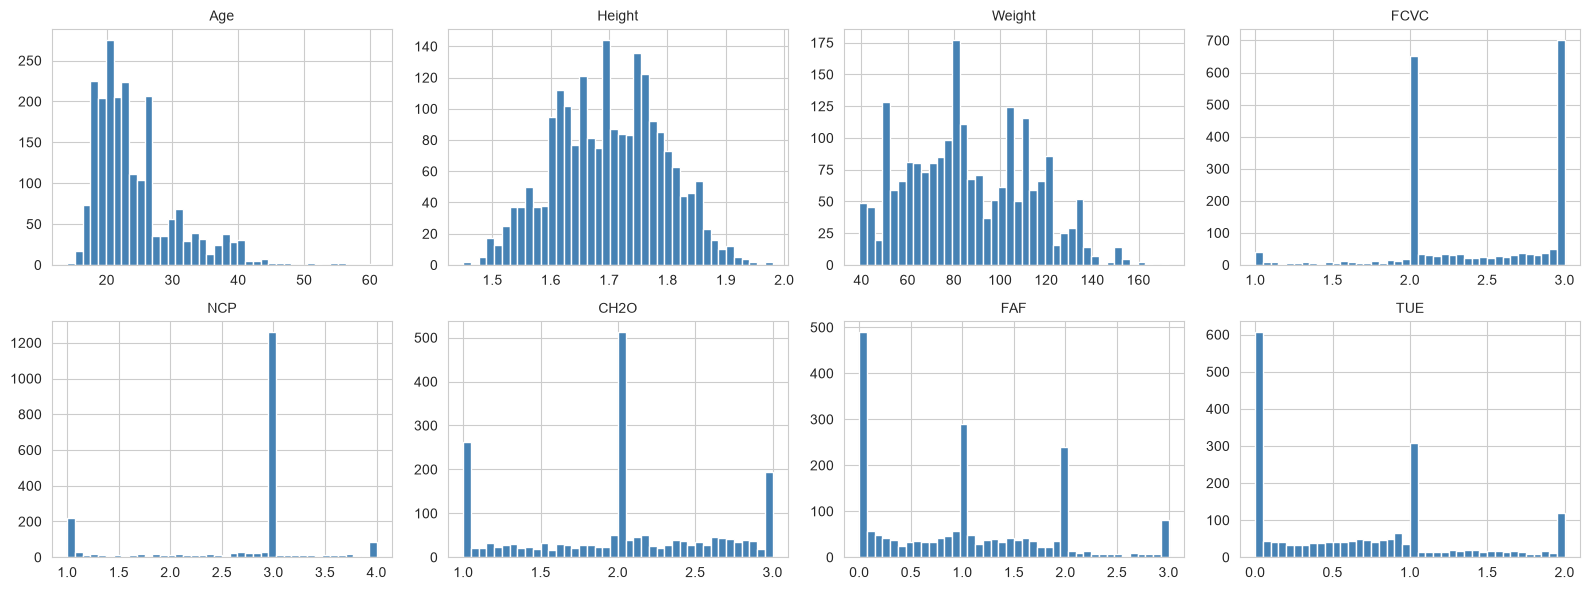

In [12]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

n_cols = len(numeric_cols)
n_rows = (n_cols + 3) // 4
fig, axes = plt.subplots(n_rows, 4, figsize=(16, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    df[col].hist(bins=40, ax=axes[i], color="steelblue", edgecolor="white")
    axes[i].set_title(col, fontsize=10)

for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

### Building correlation matrix

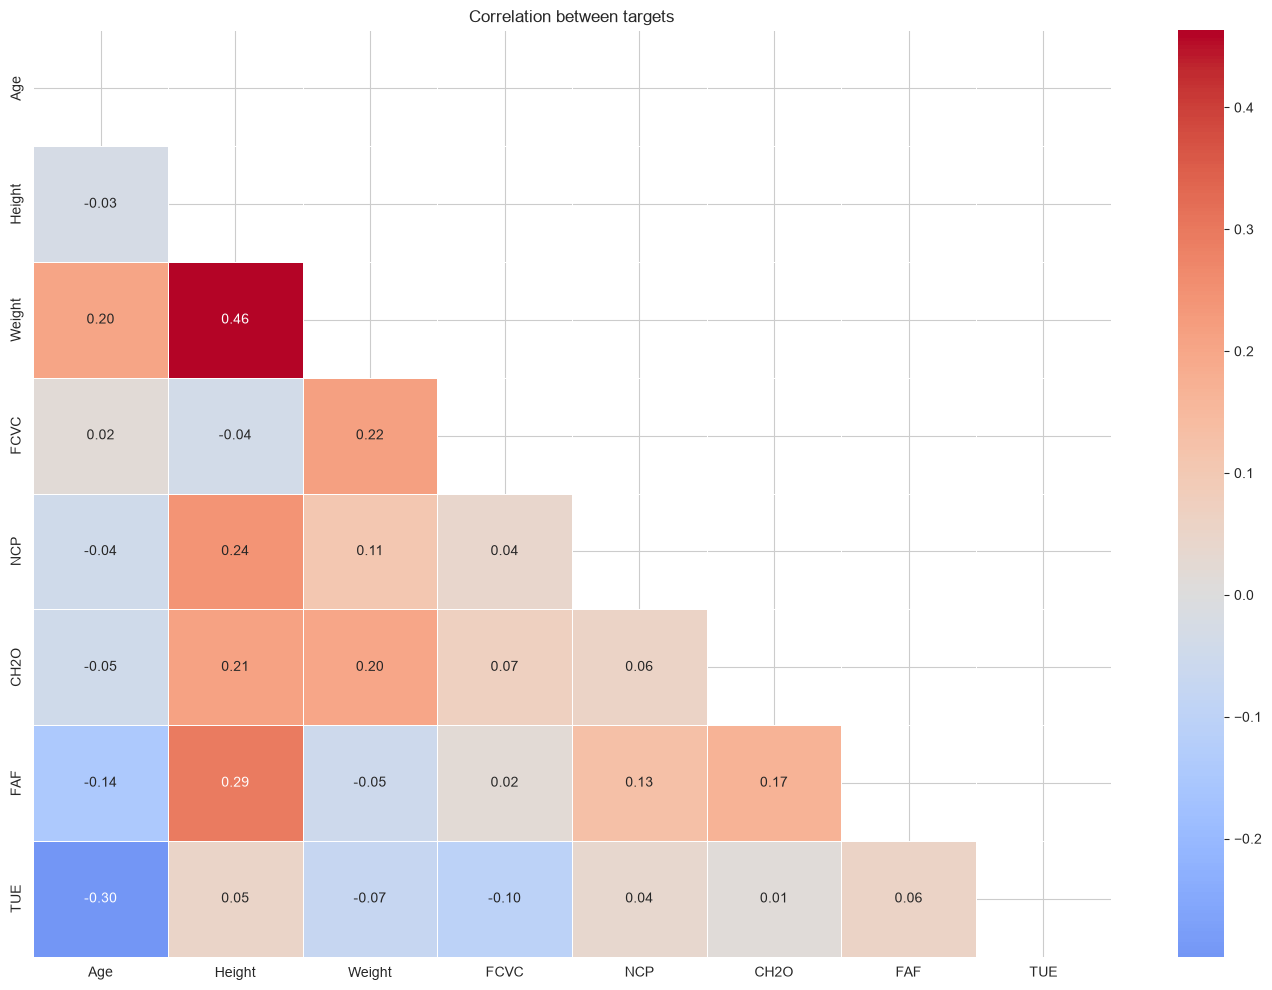

In [13]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(14, 10))
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Correlation between targets")
plt.tight_layout()
plt.show()

### Boxplot признаков по классам

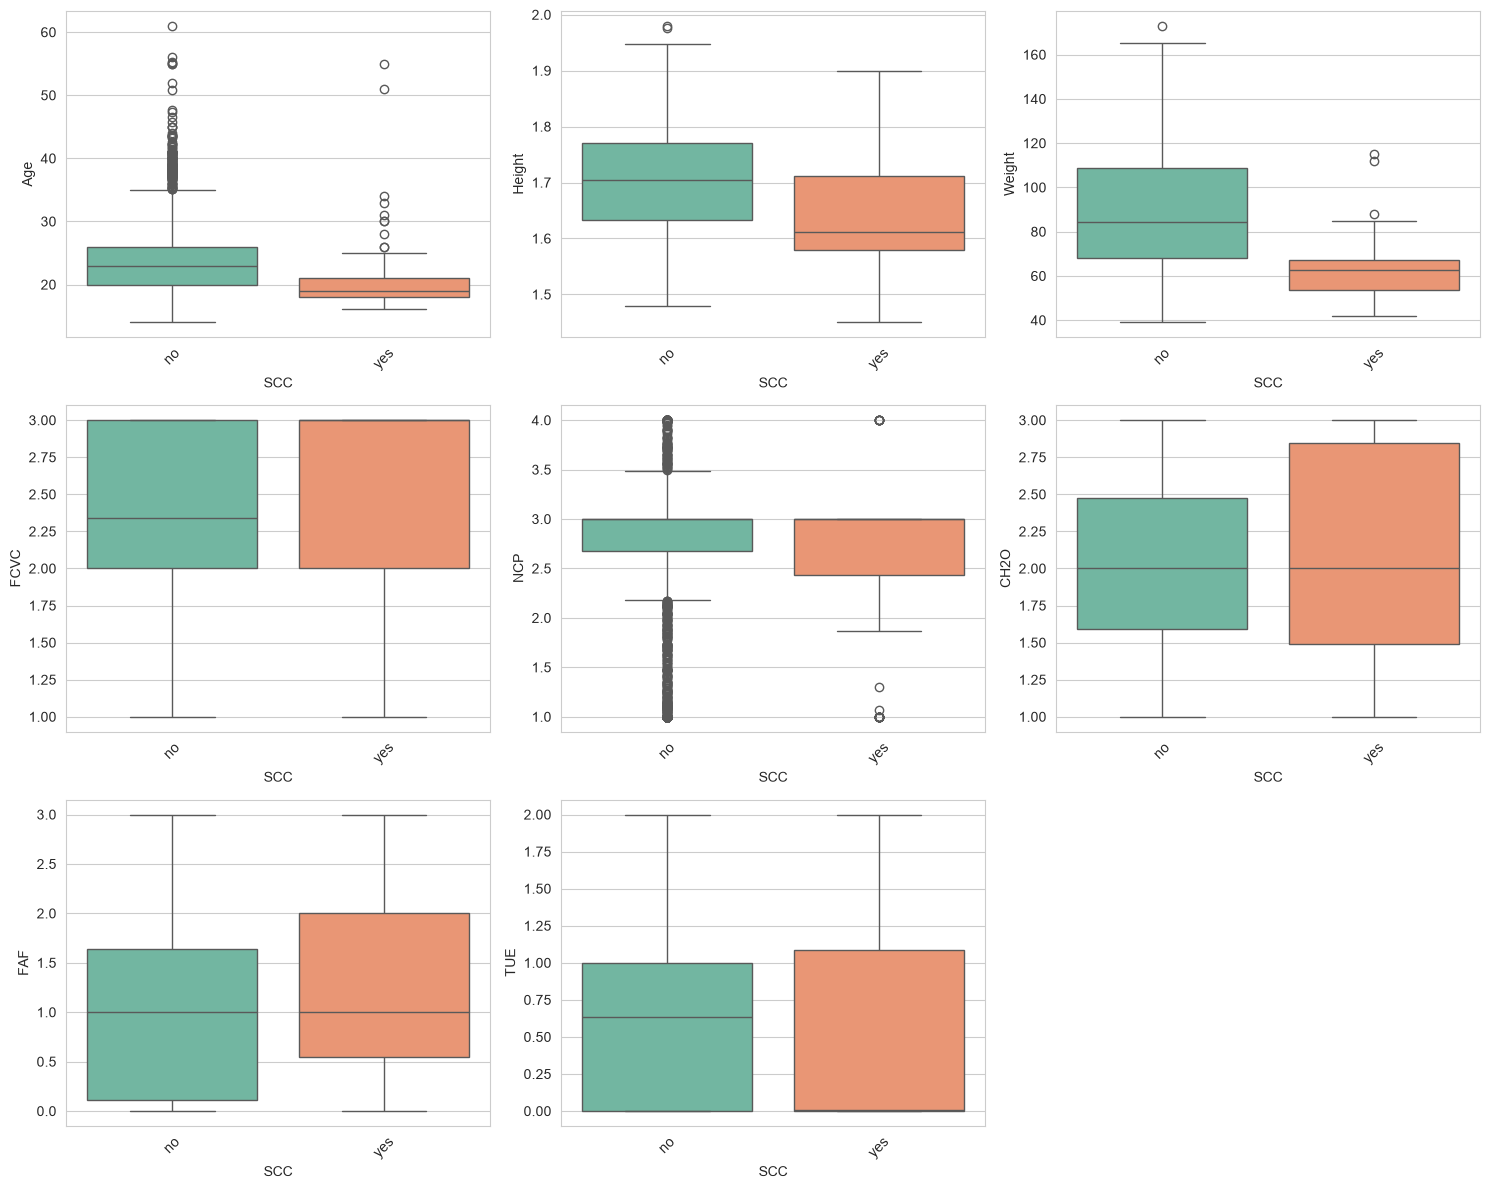

In [14]:
import math

target_col = "SCC"
top_features = numeric_cols

ncols = 3  # columns per row — a real grid width, not the feature count
nrows = math.ceil(len(top_features) / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten()

for idx, col in enumerate(top_features):
    ax = axes[idx]
    sns.boxplot(data=df, x=target_col, y=col, ax=ax, palette="Set2")
    ax.tick_params(axis="x", rotation=45)

for j in range(len(top_features), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()

### Pairplot (ключевые признаки)

KeyError: 'NObeyesdad'

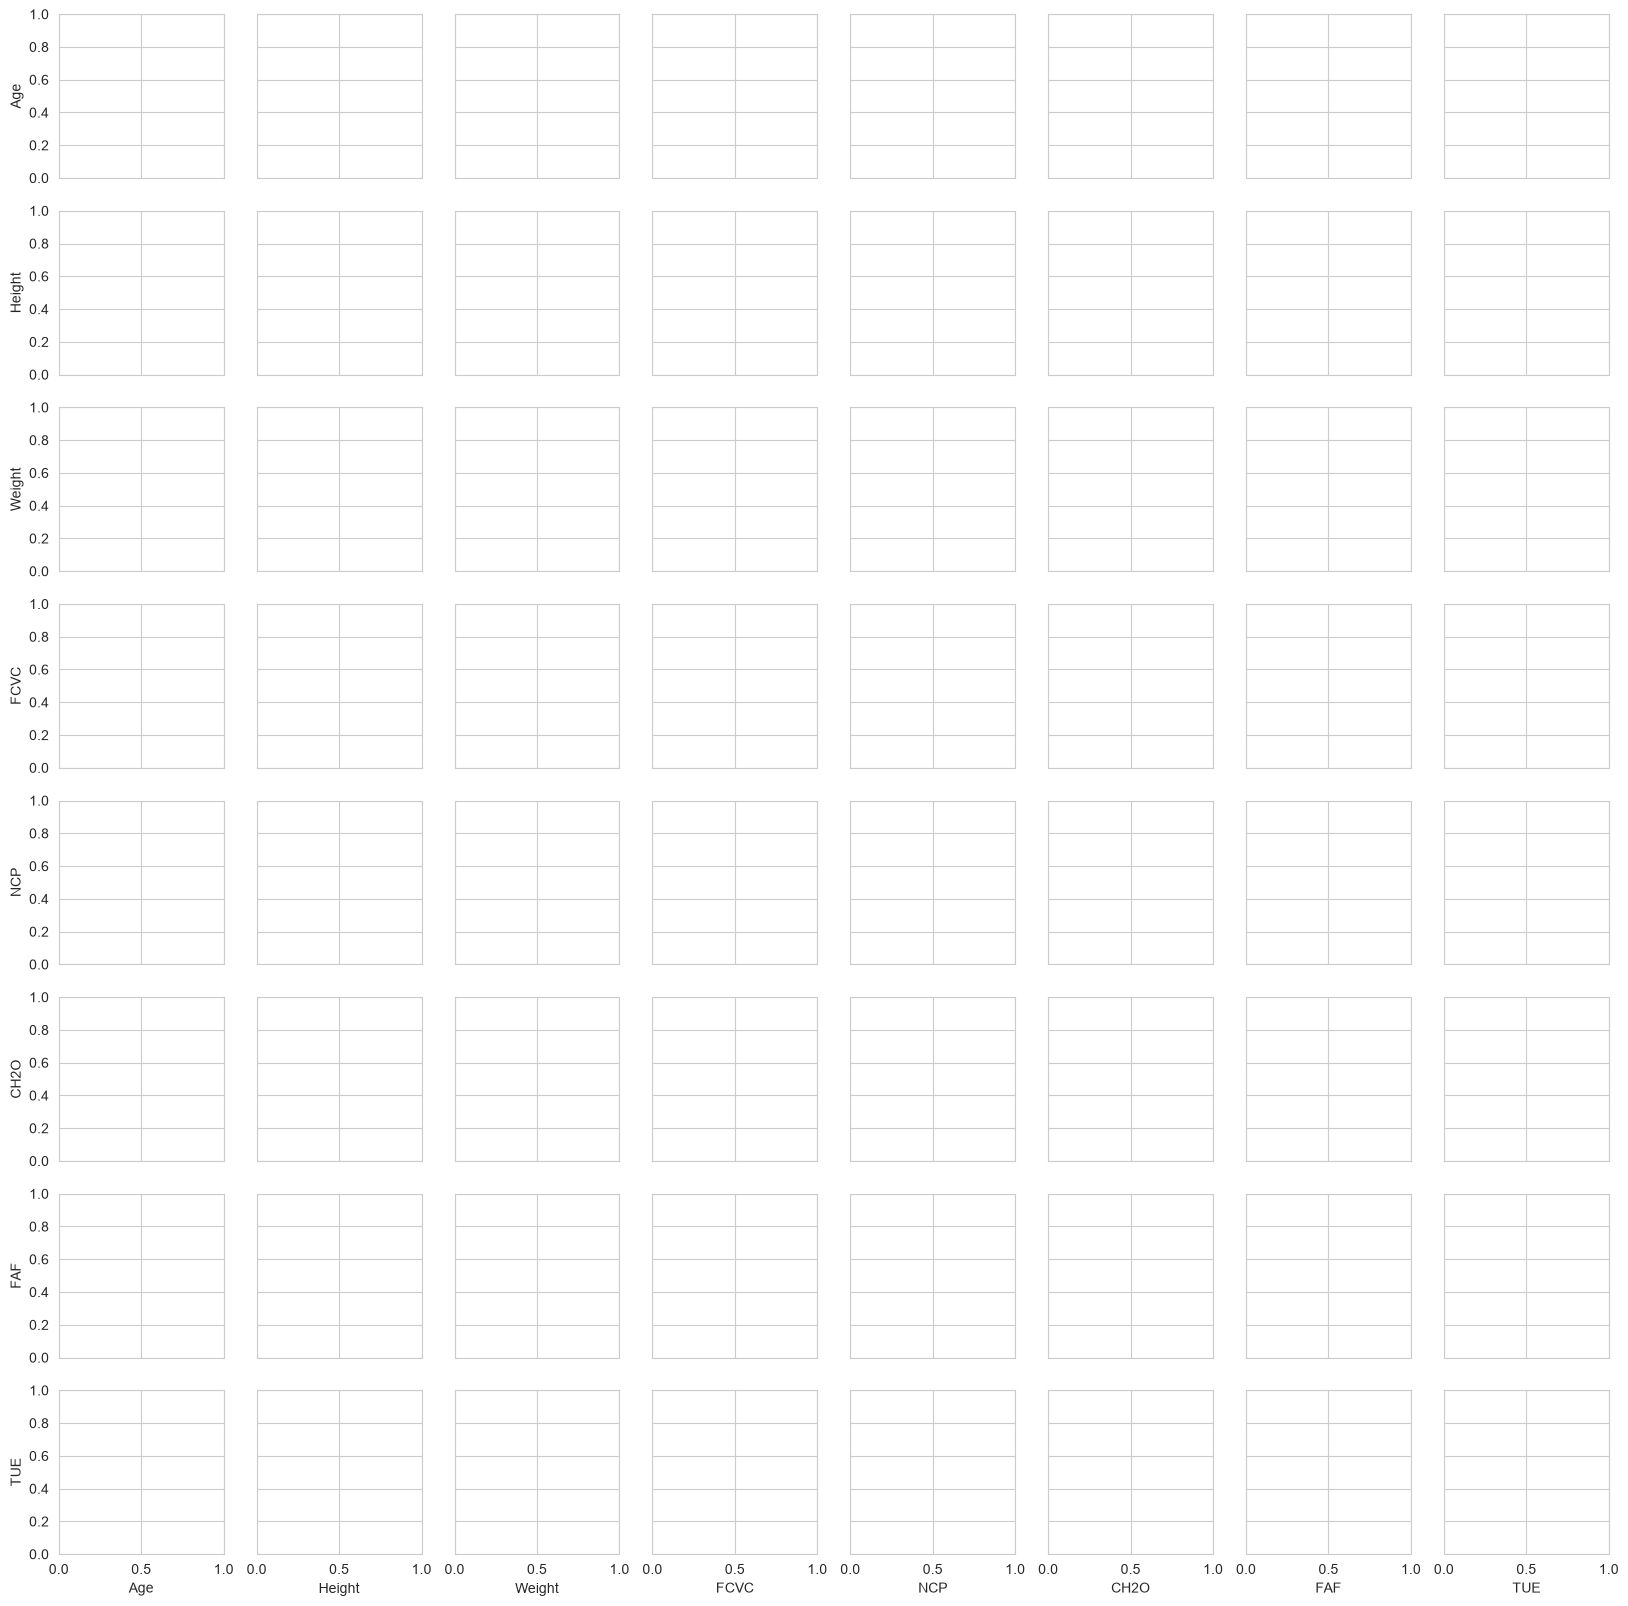

In [22]:
sns.pairplot(df[top_features],
             palette="Set2", plot_kws={"alpha": 0.4, "s": 15})
plt.show()

## 3. Подготовка данных

Работа с признаками $x = (x_1, \ldots, x_d)$ и целевой переменной $Y$.

**Важно:** используем только физически осмысленные признаки:
- **alpha, delta** — координаты на небесной сфере (прямое восхождение, склонение)
- **u, g, r, i, z** — магнитуды в 5 фотометрических фильтрах (SDSS ugriz)
- **redshift** — красное смещение (для регрессии)

Исключаем технические ID: obj_ID, run_ID, rerun_ID, cam_col, field_ID, spec_obj_ID, plate, MJD, fiber_ID.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

feature_cols = ["alpha", "delta", "u", "g", "r", "i", "z", "redshift"]
X_all = df[feature_cols].copy()

X_reg = X_all.drop(columns=["redshift"])
y_reg = X_all["redshift"].values

X_train_reg, X_test_reg, y_train_reg, y_test_reg =  train_test_split(X_reg, y_reg, test_size=0.2, random_state=123)

scaler_reg = StandardScaler() #-> (X - X_train.mean()) / X_train.std() -> [0, 1]
X_train_reg_sc = scaler_reg.fit_transform(X_train_reg)
X_test_reg_sc = scaler_reg.transform(X_test_reg)

In [ ]:
X_cls = X_all
y_cls = LabelEncoder().fit_transform( df[target_col])

X_train, X_test, y_train_cls, y_test_cls =  train_test_split(X_cls, y_cls, test_size=0.2, random_state=123, stratify=y_cls)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

### Создание бинарной задачи (для ROC, PR кривых)

Выделим бинарную подзадачу: GALAXY vs остальные (несбалансированные классы).

In [ ]:
le = LabelEncoder().fit(df[target_col])
y_bin = (df[target_col] == "GALAXY").astype(int).values

X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(
    X, y_bin, test_size=0.2, random_state=42, stratify=y_bin)

scaler_bin = StandardScaler()
X_train_bin_sc = scaler_bin.fit_transform(X_train_bin)
X_test_bin_sc = scaler_bin.transform(X_test_bin)

pd.Series(y_bin).value_counts()

## 3.5 Утечка данных: масштабирование внутри Pipeline

Если обучить `StandardScaler` на **всём** train, а потом делать кросс-валидацию, то на каждом фолде масштаб уже «подсмотрел» валидацию — это утечка. Правильно — класть предобработку в `Pipeline`: тогда она обучается только на train-части каждого фолда.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
wrong = cross_val_score(LogisticRegression(), X_train_sc, y_train_cls, cv=cv, scoring="f1_macro") #Ошибка - кросс валидация на всем трэйн скейлим

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("LogisticRegression", LogisticRegression())
])
correct = cross_val_score(pipe, X_train, y_train_cls, cv=cv, scoring="f1_macro")


fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(["С утечкой\n(scaler вне CV)", "Без утечки\n(Pipeline)"],
              [wrong.mean(), correct.mean()],
              yerr=[wrong.std(), correct.std()], capsize=6,
              color=["salmon", "mediumseagreen"])
for b, v in zip(bars, [wrong.mean(), correct.mean()]):
    ax.text(b.get_x() + b.get_width()/2, v, f"{v:.4f}", ha="center", va="bottom")
ax.set_ylabel("CV F1 (macro)"); ax.set_ylim(0, 1)
ax.set_title("Утечка при масштабировании вне Pipeline")
plt.tight_layout(); plt.show()

print(f"Разница средних CV F1: {abs(wrong.mean() - correct.mean()):.5f}")

## 4. Задача регрессии: предсказание redshift

$f: X \to \mathbb{R}$, минимизируем $\mathcal{L}(w) = \|y - Xw\|^2 + \lambda\Omega(w)$

**Redshift** (красное смещение) — ключевой параметр в астрономии, показывает удалённость и скорость объекта.

### 4.1 OLS — метод наименьших квадратов

$w^* = (X^TX)^{-1}X^Ty$

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

lr = LinearRegression().fit(X_train_reg_sc, y_train_reg)
y_pred_lr = lr.predict(X_test_reg_sc)

pd.DataFrame({
    "MSE": [mean_squared_error(y_test_reg**2, y_pred_lr)],
    "RMSE": [np.sqrt(mean_squared_error(y_test_reg, y_pred_lr))],
    "MAE": [mean_absolute_error(y_test_reg, y_pred_lr)],
    "R²": [r2_score(y_test_reg, y_pred_lr)],
}, index=["OLS"])

### 4.2 Ridge (L2), Lasso (L1), ElasticNet

- **Ridge:** $w^* = (X^TX + \lambda I)^{-1}X^Ty$ — сжимает коэффициенты
- **Lasso (L1):** обнуляет коэффициенты → отбор признаков
- **ElasticNet:** $\lambda_1\|w\|_1 + \lambda_2\|w\|^2$

In [ ]:
models_reg = {
    "OLS": LinearRegression(),
    "Ridge (a = 1)": Ridge(alpha=1),
    "Ridge (a = 100)": Ridge(alpha=100),
    "Lasso (a = 0.05)": Lasso(alpha=0.05),
    "Lasso (a = 100)": Lasso(alpha=100),
    "ElasticNet": ElasticNet(alpha=1, l1_ratio=0.05)
    
}


results_reg = []
for name, model in models_reg.items():
    model.fit(X_train_reg_sc, y_train_reg)
    y_pred = model.predict(X_test_reg_sc)
    results_reg.append({
        "Model": name,
        "RMSE": np.sqrt(mean_squared_error(y_test_reg, y_pred)),
        "MAE": mean_absolute_error(y_test_reg, y_pred),
        "R²": r2_score(y_test_reg, y_pred),
    })

pd.DataFrame(results_reg).set_index("Model").round(2)

### 4.3 Коэффициенты моделей: L1 обнуляет, L2 сжимает

In [ ]:
coefs = pd.DataFrame({
    name: model.coef_ for name, model in models_reg.items()
}, index=X_reg.columns)

fig, ax = plt.subplots(figsize=(12, 6))
coefs[["OLS", "Ridge (a = 100)", "Lasso (a = 0.05)", "ElasticNet"]].plot.bar(ax=ax)
ax.set_title("Сравнение коэффициентов: L2 сжимает, L1 обнуляет")
ax.axhline(0, color="black", linewidth=0.5)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### 4.4 Визуализация предсказаний

In [ ]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(y_test_reg, y_pred_lr, alpha=0.3, s=10)
lims = [y_test_reg.min(), y_test_reg.max()]
ax.plot(lims, lims, "r--", linewidth=2)
ax.set_xlabel("Истинное значение redshift")
ax.set_ylabel("Предсказание")
ax.set_title(f"OLS: предсказания vs реальность (R²={r2_score(y_test_reg, y_pred_lr):.3f})")
plt.tight_layout()
plt.show()

## 4.5 Градиентный спуск с нуля (линейная регрессия)

Вместо закрытой формулы OLS $w^*=(X^TX)^{-1}X^Ty$ веса можно искать итеративно:
$w \leftarrow w - \eta\,\nabla_w\mathcal{L}$, где $\mathcal{L}=\tfrac1n\|Xw-y\|^2$, $\eta$ — learning rate.

In [ ]:
def gd_linear(X, y, lr=0.1, n_iter=200):
    n, d = X.shape
    w = np.zeros(d)
    b = 0.0
    hist = []
    for k in range(n_iter):
        #lr = lr / (k + 1)
        diff = (X @ w + b - y)
        err = np.mean(diff**2) #MSE LOSS
        hist.append(err)
        """
        X^2 = X.T @ X = 2X.T
        dL/dw = 1/n * (diff).T @ (diff) = 1/n * 2 * (Xw + b-y) * X = 2/n * (X.T @ diff)
        dL/db = 1/n * 2 * (Xw + b - y) * 1 = 2/n * diff.sum()
        """
        w -= lr * (2/n) * (X.T @ diff)
        b -= lr * (2/n) * diff.sum()
    return w, b, hist


fig, ax = plt.subplots(figsize=(10, 6))
for lr in [0.01, 0.05, 0.2]:
    _, _, hist = gd_linear(X_train_reg_sc, y_train_reg, lr=lr, n_iter=200)
    ax.plot(hist, label=f"lr = {lr}")
ax.set_xlabel("Итерация"); ax.set_ylabel("MSE на train (log scale)")
ax.set_yscale("log"); ax.set_title("Сходимость градиентного спуска при разных learning rate")
ax.legend(); plt.tight_layout(); plt.show()

In [ ]:
w_gd, b_gd, _ = gd_linear(X_train_reg_sc, y_train_reg, lr=0.2, n_iter=500)
y_pred_gd = X_test_reg_sc @ w_gd + b_gd
ols = LinearRegression().fit(X_train_reg_sc, y_train_reg)

pd.DataFrame({
    "RMSE": [np.sqrt(mean_squared_error(y_test_reg, y_pred_gd)),
             np.sqrt(mean_squared_error(y_test_reg, ols.predict(X_test_reg_sc)))],
    "R²": [r2_score(y_test_reg, y_pred_gd), r2_score(y_test_reg, ols.predict(X_test_reg_sc))],
}, index=["Gradient Descent (с нуля)", "OLS (закрытая формула)"]).round(4)

## 5. Бинарная классификация: Logistic Regression

$P(y=1|x) = \sigma(w^Tx) = \frac{1}{1+e^{-w^Tx}}$

Задача: GALAXY vs остальные (несбалансированные классы).

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report, log_loss,
                             roc_auc_score, roc_curve, precision_recall_curve, average_precision_score,
                             ConfusionMatrixDisplay)

log_reg_bin = LogisticRegression(max_iter=1000, random_state=1).fit(X_train_bin_sc, y_train_bin)
y_pred_bin = log_reg_bin.predict(X_test_bin_sc)
y_proba_bin = log_reg_bin.predict_proba(X_test_bin_sc)[:, 1]

f1_score(y_test_bin, y_pred_bin)

### 5.1 Confusion Matrix

| | Predicted 0 | Predicted 1 |
|---|---|---|
| **Actual 0** | TN | FP |
| **Actual 1** | FN | TP |

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test_bin, y_pred_bin, ax=ax, cmap="Blues")
ax.set_title("Confusion Matrix (бинарная)")
plt.tight_layout()
plt.show()

### 5.2 Precision, Recall, F1, Log-Loss

$\text{Precision} = \frac{TP}{TP+FP}$, $\text{Recall} = \frac{TP}{TP+FN}$, $F_1 = 2\frac{P \cdot R}{P+R}$

In [ ]:
pd.DataFrame({
    "Accuracy": [accuracy_score(y_test_bin, y_pred_bin)],
    "Precision": [precision_score(y_test_bin, y_pred_bin)],
    "Recall": [recall_score(y_test_bin, y_pred_bin)],
    "F1": [f1_score(y_test_bin, y_pred_bin)],
    "Log-Loss": [log_loss(y_test_bin, y_proba_bin)],
    "ROC-AUC": [roc_auc_score(y_test_bin, y_proba_bin)],
}, index=["LogReg (binary)"]).round(4)

### 5.3 ROC-кривая и PR-кривая

**ROC:** TPR vs FPR при разных порогах $\tau$. AUC = 0.5 для случайной модели.

**PR:** Precision vs Recall — лучше при несбалансированных классах.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fpr, tpr, _ = roc_curve(y_test_bin, y_proba_bin)
axes[0].plot(fpr, tpr, linewidth=2, label=f"LogReg (AUC={roc_auc_score(y_test_bin, y_proba_bin):.3f})")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.5, label="Random (AUC=0.5)")
axes[0].set_xlabel("FPR")
axes[0].set_ylabel("TPR")
axes[0].set_title("ROC-кривая")
axes[0].legend()

prec, rec, _ = precision_recall_curve(y_test_bin, y_proba_bin)
ap = average_precision_score(y_test_bin, y_proba_bin)
axes[1].plot(rec, prec, linewidth=2, label=f"LogReg (AP={ap:.3f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("PR-кривая")
axes[1].legend()

plt.tight_layout()
plt.show()

### 5.4 Влияние порога $\tau$ на метрики

$\hat{y} = \mathbb{I}[P(y=1|x) > \tau]$

In [ ]:
thresholds = np.arange(0.05, 0.95, 0.05)
metrics_by_t = []
for t in thresholds:
    y_t = (y_proba_bin >= t).astype(int)
    metrics_by_t.append({
        "threshold": t,
        "precision": precision_score(y_test_bin, y_t, zero_division=0),
        "recall": recall_score(y_test_bin, y_t, zero_division=0),
        "f1": f1_score(y_test_bin, y_t, zero_division=0),
    })
df_t = pd.DataFrame(metrics_by_t)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df_t["threshold"], df_t["precision"], "o-", label="Precision")
ax.plot(df_t["threshold"], df_t["recall"], "s-", label="Recall")
ax.plot(df_t["threshold"], df_t["f1"], "^-", label="F1")
ax.set_xlabel("Порог τ")
ax.set_ylabel("Значение метрики")
ax.set_title("Precision / Recall / F1 при разных порогах")
ax.legend()
plt.tight_layout()
plt.show()

### 5.5 Выбор оптимального порога и `class_weight`

Порог 0.5 не оптимален при дисбалансе. Найдём $\tau^*$, максимизирующий F1, и сравним с моделью `class_weight="balanced"`.

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

taus = np.linspace(0.05, 0.95, 91)
f1s = [f1_score(y_test_bin, (y_proba_bin >= t).astype(int)) for t in taus]
tau_star = taus[int(np.argmax(f1s))]


fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(taus, f1s)
axes[0].axvline(tau_star, color="red", ls="--", label=f"τ* = {tau_star:.2f}")
axes[0].axvline(0.5, color="gray", ls=":", label="τ = 0.50")
axes[0].set_xlabel("Порог τ"); axes[0].set_ylabel("F1"); axes[0].set_title("F1 по порогу"); axes[0].legend()
for ax, t, name in [(axes[1], 0.5, "τ = 0.50"), (axes[2], tau_star, f"τ* = {tau_star:.2f}")]:
    cm = confusion_matrix(y_test_bin, (y_proba_bin >= t).astype(int))
    ConfusionMatrixDisplay(cm).plot(ax=ax, cmap="Blues", colorbar=False)
    f1v = f1_score(y_test_bin, (y_proba_bin >= t).astype(int))
    ax.set_title(f"Confusion Matrix ({name})\nF1 = {f1v:.3f}")
plt.tight_layout(); plt.show()

In [ ]:
log_reg_bal = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=1).fit(X_train_bin_sc, y_train_bin)
y_pred_bal = log_reg_bal.predict(X_test_bin_sc)
y_proba_bal = log_reg_bal.predict_proba(X_test_bin_sc)[:, 1]

def _row(pred, proba):
    return [precision_score(y_test_bin, pred), recall_score(y_test_bin, pred),
            f1_score(y_test_bin, pred), roc_auc_score(y_test_bin, proba)]

pd.DataFrame(
    [_row(y_pred_bin, y_proba_bin),
     _row((y_proba_bin >= tau_star).astype(int), y_proba_bin),
     _row(log_reg_bal.predict(X_test_bin_sc), y_proba_bal)],
    columns=["Precision", "Recall", "F1", "ROC-AUC"],
    index=["LogReg τ=0.5", "LogReg τ*", "LogReg class_weight="balanced""]).round(4)

### 5.6 Калибровка вероятностей

Насколько предсказанные вероятности соответствуют реальной частоте положительного класса (reliability diagram).

In [ ]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(y_test_bin, y_proba_bin, n_bins=10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot([0, 1], [0, 1], "k--", label="Идеальная калибровка")
axes[0].plot(prob_pred, prob_true, "o-", label="LogReg")
axes[0].set_xlabel("Средняя предсказанная вероятность"); axes[0].set_ylabel("Доля положительных")
axes[0].set_title("Калибровочная кривая"); axes[0].legend()
axes[1].hist(y_proba_bin, bins=30, color="steelblue", edgecolor="white")
axes[1].set_xlabel("Предсказанная вероятность P(y=1)"); axes[1].set_ylabel("Количество")
axes[1].set_title("Распределение предсказанных вероятностей")
plt.tight_layout(); plt.show()

### 5.7 Граница решения (2 признака)

Как разные модели делят пространство: логистическая регрессия — прямой, дерево — «ступеньками».

In [ ]:
from sklearn.tree import DecisionTreeClassifier



xmin, xmax = Xb2_te_s[:, 0].min() - 0.5, Xb2_te_s[:, 0].max() + 0.5
ymin, ymax = Xb2_te_s[:, 1].min() - 0.5, Xb2_te_s[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(xmin, xmax, 300), np.linspace(ymin, ymax, 300))
grid = np.c_[xx.ravel(), yy.ravel()]

rng = np.random.RandomState(42)
idx = rng.choice(len(Xb2_te_s), size=min(2000, len(Xb2_te_s)), replace=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, model, name in [(axes[0], lr2, "Logistic Regression"), (axes[1], dt2, "Decision Tree (d=5)")]:
    Z = model.predict(grid).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.25, cmap="coolwarm")
    ax.scatter(Xb2_te_s[idx, 0], Xb2_te_s[idx, 1], c=yb_te[idx], cmap="coolwarm", s=10, alpha=0.6)
    ax.set_xlabel(f"{f1n} (норм.)"); ax.set_ylabel(f"{f2n} (норм.)")
    ax.set_title(f"Граница решения — {name}")
plt.tight_layout(); plt.show()

## 6. Многоклассовая классификация (Softmax)

$P(y=k|x) = \frac{e^{w_k^T x}}{\sum_j e^{w_j^T x}}$, $\hat{y} = \arg\max_k P(y=k|x)$

3 класса: STAR, GALAXY, QSO. Стратегии OvR и multinomial (softmax).

In [ ]:
from sklearn.multiclass import OneVsRestClassifier
class_names = le.classes_

log_reg_ovr = OneVsRestClassifier(LogisticRegression(max_iter=1000, random_state=42)).fit(X_train_sc, y_train_cls)
log_reg_mn = LogisticRegression(max_iter=1000, random_state=42).fit(X_train_sc, y_train_cls)

y_pred_ovr = log_reg_ovr.predict(X_test_sc)
y_pred_mn = log_reg_mn.predict(X_test_sc)

pd.DataFrame({
    "OvR Accuracy": [accuracy_score(y_test_cls, y_pred_ovr)],
    "OvR F1 (macro)": [f1_score(y_test_cls, y_pred_ovr, average="macro")],
    "Softmax Accuracy": [accuracy_score(y_test_cls, y_pred_mn)],
    "Softmax F1 (macro)": [f1_score(y_test_cls, y_pred_mn, average="macro")],
}, index=["LogReg"]).round(4)

### 6.1 Confusion Matrix (многоклассовая)

In [ ]:
fig, ax = plt.subplots(figsize=(9, 7))
ConfusionMatrixDisplay.from_predictions(y_test_cls, y_pred_mn, display_labels=class_names, ax=ax, cmap="Blues")
ax.set_title("Confusion Matrix — Softmax LogReg")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### 6.2 Classification Report (Precision, Recall, F1 по каждому классу)

In [ ]:
report = classification_report(y_test_cls, y_pred_mn, target_names=class_names, output_dict=True)
pd.DataFrame(report).T.round(3)

## 7. Деревья решений

Рекурсивное разбиение: в каждом узле выбираем $(j^*, t^*)$ минимизирующие $N_L H(D_L) + N_R H(D_R)$.

Критерии: **Gini** $= 1 - \sum p_k^2$, **Entropy** $= -\sum p_k \log p_k$, **MSE** для регрессии.

### 7.1 Дерево для классификации

In [ ]:
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree

dt_cls = DecisionTreeClassifier(max_depth=5, random_state=42, criterion="gini")
dt_cls.fit(X_train, y_train_cls)
y_pred_dt = dt_cls.predict(X_test)

pd.DataFrame({
    "Accuracy": [accuracy_score(y_test_cls, y_pred_dt)],
    "F1 (macro)": [f1_score(y_test_cls, y_pred_dt, average="macro")],
}, index=["DecisionTree (depth=5)"]).round(4)

### 7.2 Визуализация дерева

Каждый узел: условие $[x_j < t]$, Gini, количество объектов, предсказание.

In [ ]:
numeric_cols = X.columns.tolist()

plt.figure(figsize=(24, 10))
plot_tree(dt_cls, max_depth=3, feature_names=numeric_cols,
          class_names=class_names.tolist(), filled=True, rounded=True, fontsize=8)
plt.title("Decision Tree (первые 3 уровня)")
plt.tight_layout()
plt.show()

### 7.3 Дерево для регрессии (предсказание redshift)

Критерий: MSE = $\text{Var}(y)$ в узле. Предсказание в листе: $c_m = \bar{y}_m$.

In [ ]:
dt_reg = DecisionTreeRegressor(max_depth=8, random_state=42, criterion="squared_error")
dt_reg.fit(X_train_reg, y_train_reg)
y_pred_dt_reg = dt_reg.predict(X_test_reg)

pd.DataFrame({
    "RMSE": [np.sqrt(mean_squared_error(y_test_reg, y_pred_dt_reg))],
    "MAE": [mean_absolute_error(y_test_reg, y_pred_dt_reg)],
    "R²": [r2_score(y_test_reg, y_pred_dt_reg)],
}, index=["DecisionTree Regressor"]).round(4)

## 7.5 Ансамбли: Random Forest и Gradient Boosting

Одно дерево склонно к переобучению. Ансамбли усредняют много деревьев (bagging → Random Forest)
или строят их последовательно (boosting → Gradient Boosting), снижая variance/bias.

In [ ]:
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

ensemble_models = {
    "DecisionTree (d=5)": DecisionTreeClassifier(max_depth=5, random_state=42),
    "RandomForest (200)": RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    "HistGradientBoosting": HistGradientBoostingClassifier(random_state=42),
}
ens_res = []
for name, model in ensemble_models.items():
    model.fit(X_train, y_train_cls)
    yp = model.predict(X_test)
    ens_res.append({"Model": name, "Accuracy": accuracy_score(y_test_cls, yp),
                    "F1 (macro)": f1_score(y_test_cls, yp, average="macro")})
df_ens = pd.DataFrame(ens_res).set_index("Model")

fig, ax = plt.subplots(figsize=(9, 5))
df_ens.plot.bar(ax=ax)
ax.set_ylim(0.8, 1.0); ax.set_ylabel("Значение метрики")
ax.set_title("Одно дерево vs ансамбли"); ax.tick_params(axis="x", rotation=15); ax.legend(loc="lower right")
plt.tight_layout(); plt.show()
df_ens.round(4)

In [ ]:
rf_imp = pd.Series(ensemble_models["RandomForest (200)"].feature_importances_,
                   index=X.columns).sort_values()
fig, ax = plt.subplots(figsize=(10, 6))
rf_imp.plot.barh(ax=ax, color="seagreen")
ax.set_title("Feature Importance — Random Forest"); ax.set_xlabel("Importance")
plt.tight_layout(); plt.show()

### 7.6 ROC и PR-кривые нескольких моделей (бинарная задача)

Сравним LogReg, дерево и Random Forest на задаче GALAXY vs остальные.

In [ ]:
models_bin = {
    "LogReg": LogisticRegression(max_iter=1000, random_state=42),
    "DecisionTree (d=8)": DecisionTreeClassifier(max_depth=8, random_state=42),
    "RandomForest (200)": RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
}
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, model in models_bin.items():
    model.fit(X_train_bin_sc, y_train_bin)
    proba = model.predict_proba(X_test_bin_sc)[:, 1]
    fpr, tpr, _ = roc_curve(y_test_bin, proba)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test_bin, proba):.3f})")
    prec, rec, _ = precision_recall_curve(y_test_bin, proba)
    axes[1].plot(rec, prec, label=f"{name} (AP={average_precision_score(y_test_bin, proba):.3f})")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.5)
axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR"); axes[0].set_title("ROC"); axes[0].legend()
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision"); axes[1].set_title("PR"); axes[1].legend()
plt.tight_layout(); plt.show()

## 8. Переобучение и Bias-Variance Tradeoff

$\mathbb{E}[(y - f(x))^2] = \text{Bias}^2 + \text{Variance} + \sigma^2$

- **High Bias** (underfitting): слишком простая модель
- **High Variance** (overfitting): слишком сложная модель

Демонстрация: как глубина дерева влияет на train/test ошибку.

In [ ]:
depths = range(1, 30)
train_acc, test_acc = [], []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42).fit(X_train, y_train_cls)
    train_acc.append(accuracy_score(y_train_cls, dt.predict(X_train)))
    test_acc.append(accuracy_score(y_test_cls, dt.predict(X_test)))

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(depths, train_acc, "o-", label="Train Accuracy")
ax.plot(depths, test_acc, "s-", label="Test Accuracy")
ax.axvline(x=depths[np.argmax(test_acc)], color="red", linestyle="--", alpha=0.5,
           label=f"Best depth={depths[np.argmax(test_acc)]}")
ax.set_xlabel("max_depth")
ax.set_ylabel("Accuracy")
ax.set_title("Bias-Variance Tradeoff: глубина дерева")
ax.legend()
plt.tight_layout()
plt.show()

### 8.1 Регуляризация деревьев: min_samples_leaf

In [ ]:
leafs = [1, 2, 5, 10, 20, 50, 100, 200]
train_f1, test_f1 = [], []

for ml in leafs:
    dt = DecisionTreeClassifier(min_samples_leaf=ml, random_state=42).fit(X_train, y_train_cls)
    train_f1.append(f1_score(y_train_cls, dt.predict(X_train), average="macro"))
    test_f1.append(f1_score(y_test_cls, dt.predict(X_test), average="macro"))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(leafs, train_f1, "o-", label="Train F1")
ax.plot(leafs, test_f1, "s-", label="Test F1")
ax.set_xlabel("min_samples_leaf")
ax.set_ylabel("F1 (macro)")
ax.set_title("Регуляризация дерева через min_samples_leaf")
ax.legend()
plt.tight_layout()
plt.show()

### 8.3 Кривые обучения (learning curve)

Показывают, как train/validation качество меняется с ростом объёма обучающих данных —
помогает отличить high bias (обе кривые низко) от high variance (большой разрыв).

In [ ]:
from sklearn.model_selection import learning_curve

sizes, train_sc, val_sc = learning_curve(
    LogisticRegression(max_iter=1000, random_state=42),
    X_train_sc, y_train_cls, train_sizes=np.linspace(0.1, 1.0, 6),
    cv=3, scoring="f1_macro", n_jobs=-1)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(sizes, train_sc.mean(1), "o-", label="Train F1")
ax.fill_between(sizes, train_sc.mean(1) - train_sc.std(1), train_sc.mean(1) + train_sc.std(1), alpha=0.15)
ax.plot(sizes, val_sc.mean(1), "s-", label="Validation F1")
ax.fill_between(sizes, val_sc.mean(1) - val_sc.std(1), val_sc.mean(1) + val_sc.std(1), alpha=0.15)
ax.set_xlabel("Размер обучающей выборки"); ax.set_ylabel("F1 (macro)")
ax.set_title("Кривая обучения (LogReg)"); ax.legend()
plt.tight_layout(); plt.show()

### 8.2 Gini vs Entropy

Сравним два критерия разбиения.

In [ ]:
results_crit = []
for crit in ["gini", "entropy"]:
    for d in [3, 5, 10, None]:
        dt = DecisionTreeClassifier(criterion=crit, max_depth=d, random_state=42).fit(X_train, y_train_cls)
        results_crit.append({
            "criterion": crit,
            "max_depth": d,
            "train_acc": accuracy_score(y_train_cls, dt.predict(X_train)),
            "test_acc": accuracy_score(y_test_cls, dt.predict(X_test)),
        })
pd.DataFrame(results_crit).round(4)

## 9. Кросс-валидация и подбор гиперпараметров

**K-Fold CV:** разбиваем train на $K$ частей, обучаем на $K-1$, валидируем на 1. Повторяем $K$ раз.

**Stratified K-Fold:** сохраняет пропорции классов.

### 9.1 Простая кросс-валидация

In [ ]:
from sklearn.model_selection import cross_val_score, StratifiedKFold, GridSearchCV, RandomizedSearchCV

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models_cv = {
    "LogReg": LogisticRegression(max_iter=1000, random_state=42),
    "DecisionTree (d=5)": DecisionTreeClassifier(max_depth=5, random_state=42),
    "DecisionTree (d=None)": DecisionTreeClassifier(random_state=42),
}

cv_results = []
for name, model in models_cv.items():
    scores = cross_val_score(model, X_train_sc, y_train_cls, cv=cv, scoring="f1_macro")
    cv_results.append({"Model": name, "CV F1 mean": scores.mean(), "CV F1 std": scores.std()})

pd.DataFrame(cv_results).set_index("Model").round(4)

### 9.2 GridSearchCV — подбор гиперпараметров дерева

In [ ]:
param_grid = {
    "max_depth": [3, 5, 7, 10, 15, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10],
    "criterion": ["gini", "entropy"],
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid, cv=cv, scoring="f1_macro", n_jobs=-1
)
grid_search.fit(X_train_sc, y_train_cls)

grid_search.best_params_, grid_search.best_score_.round(4)

### 9.3 RandomizedSearchCV — эффективнее при большом пространстве

In [ ]:
from scipy.stats import randint, uniform

param_dist = {
    "max_depth": randint(2, 30),
    "min_samples_split": randint(2, 50),
    "min_samples_leaf": randint(1, 30),
    "criterion": ["gini", "entropy"],
}

rand_search = RandomizedSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_dist, n_iter=100, cv=cv, scoring="f1_macro", random_state=42, n_jobs=-1
)
rand_search.fit(X_train_sc, y_train_cls)

rand_search.best_params_, rand_search.best_score_.round(4)

### 9.4 GridSearchCV для Ridge-регрессии: подбор $\lambda$

In [ ]:
alphas = np.logspace(-4, 3, 50)
grid_ridge = GridSearchCV(
    Ridge(), {"alpha": alphas}, cv=5, scoring="r2", n_jobs=-1
)
grid_ridge.fit(X_train_reg_sc, y_train_reg)

fig, ax = plt.subplots(figsize=(10, 5))
ax.semilogx(alphas, grid_ridge.cv_results_["mean_test_score"], "o-")
ax.axvline(grid_ridge.best_params_["alpha"], color="red", linestyle="--",
           label=f"Best α={grid_ridge.best_params_["alpha"]:.4f}")
ax.set_xlabel("α (lambda)")
ax.set_ylabel("CV R²")
ax.set_title("Ridge: подбор коэффициента регуляризации")
ax.legend()
plt.tight_layout()
plt.show()

## 10. Финальное сравнение моделей

### 10.1 Классификация (3 класса: STAR / GALAXY / QSO)

In [ ]:
final_models_cls = {
    "LogReg (OvR)": OneVsRestClassifier(LogisticRegression(max_iter=1000, random_state=42)),
    "LogReg (Softmax)": LogisticRegression(max_iter=1000, random_state=42),
    "LogReg (L1)": LogisticRegression(penalty="l1", solver="saga", max_iter=2000, random_state=42),
    "DT (depth=5)": DecisionTreeClassifier(max_depth=5, random_state=42),
    "DT (GridSearch best)": grid_search.best_estimator_,
    "DT (RandomSearch best)": rand_search.best_estimator_,
}

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
final_models_cls["kNN (k=15)"] = KNeighborsClassifier(n_neighbors=15)
final_models_cls["Naive Bayes"] = GaussianNB()

final_cls = []
for name, model in final_models_cls.items():
    scores = cross_val_score(model, X_train_sc, y_train_cls, cv=cv, scoring="f1_macro")
    model.fit(X_train_sc, y_train_cls)
    y_pred = model.predict(X_test_sc)
    final_cls.append({
        "Model": name,
        "CV F1 (mean±std)": f"{scores.mean():.4f}±{scores.std():.4f}",
        "Test Accuracy": accuracy_score(y_test_cls, y_pred),
        "Test F1 (macro)": f1_score(y_test_cls, y_pred, average="macro"),
    })

pd.DataFrame(final_cls).set_index("Model").round(4)

### 10.2 Регрессия (предсказание redshift)

In [ ]:
final_models_reg = {
    "OLS": LinearRegression(),
    "Ridge (best α)": Ridge(alpha=grid_ridge.best_params_["alpha"]),
    "Lasso (α=1)": Lasso(alpha=1),
    "ElasticNet": ElasticNet(alpha=1, l1_ratio=0.5),
    "DT Regressor (d=8)": DecisionTreeRegressor(max_depth=8, random_state=42),
    "DT Regressor (d=None)": DecisionTreeRegressor(random_state=42),
}

final_reg = []
for name, model in final_models_reg.items():
    model.fit(X_train_reg_sc, y_train_reg)
    y_pred = model.predict(X_test_reg_sc)
    final_reg.append({
        "Model": name,
        "RMSE": np.sqrt(mean_squared_error(y_test_reg, y_pred)),
        "MAE": mean_absolute_error(y_test_reg, y_pred),
        "R²": r2_score(y_test_reg, y_pred),
    })

pd.DataFrame(final_reg).set_index("Model").round(2)

## 11. Анализ признаков (Feature Importance)

### 11.1 Важность признаков по дереву решений

In [ ]:
best_dt = grid_search.best_estimator_
importances = pd.Series(best_dt.feature_importances_, index=numeric_cols).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
importances.plot.barh(ax=ax, color="steelblue")
ax.set_title("Feature Importance (Decision Tree)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

### 11.1b Permutation Importance

Честнее, чем `feature_importances_` дерева (смещённое к признакам с большим числом значений):
измеряет падение метрики при перемешивании каждого признака.

In [ ]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(best_dt, X_test, y_test_cls, n_repeats=10,
                              random_state=42, scoring="f1_macro", n_jobs=-1)
order = perm.importances_mean.argsort()

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(np.array(numeric_cols)[order], perm.importances_mean[order],
        xerr=perm.importances_std[order], color="mediumpurple", capsize=3)
ax.set_title("Permutation Importance (Decision Tree)")
ax.set_xlabel("Падение F1 при перемешивании признака")
plt.tight_layout(); plt.show()

### 11.2 Коэффициенты логистической регрессии (Softmax)

$w_k$ — вес признака для класса $k$.

In [ ]:
coef_df = pd.DataFrame(log_reg_mn.coef_, columns=numeric_cols, index=class_names)

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(coef_df, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax)
ax.set_title("Коэффициенты Softmax LogReg по классам")
ax.set_ylabel("Класс")
plt.tight_layout()
plt.show()

### 11.3 L1-отбор признаков (Lasso)

Lasso обнуляет неважные коэффициенты → автоматический отбор признаков.

In [ ]:
l1_model = LogisticRegression(penalty="l1", solver="saga", C=0.1, max_iter=3000, random_state=42,
                              )
l1_model.fit(X_train_sc, y_train_cls)

l1_coef = pd.DataFrame(l1_model.coef_, columns=numeric_cols, index=class_names)
nonzero = (l1_coef != 0).sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

nonzero.sort_values().plot.barh(ax=axes[0], color="coral")
axes[0].set_title("Количество ненулевых коэффициентов (из 7 классов)")
axes[0].set_xlabel("Ненулевых")

sns.heatmap(l1_coef, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=axes[1])
axes[1].set_title("L1 LogReg: разреженные коэффициенты")

plt.tight_layout()
plt.show()

## 11.5 Отбор признаков (Feature Selection)

Методы отбора признаков:
1. **Filter methods:** статистические критерии (корреляция, mutual information, chi2)
2. **Wrapper methods:** RFE (Recursive Feature Elimination)
3. **Embedded methods:** L1/Lasso, Tree importance (уже рассмотрели)
4. **Variance Threshold:** удаление низковариативных признаков

### 11.5.1 Variance Threshold — удаление низковариативных признаков

In [ ]:
from sklearn.feature_selection import VarianceThreshold

variances = X_train_sc.var(axis=0)
var_df = pd.DataFrame({"Feature": X.columns, "Variance": variances}).sort_values("Variance")

fig, ax = plt.subplots(figsize=(10, 6))
var_df.plot.barh(x="Feature", y="Variance", ax=ax, color="steelblue", legend=False)
ax.set_title("Variance по признакам (нормализованные данные)")
ax.set_xlabel("Variance")
plt.tight_layout()
plt.show()

### 11.5.2 Univariate Feature Selection — SelectKBest с f_classif / mutual_info

In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif

f_selector = SelectKBest(f_classif, k="all").fit(X_train_sc, y_train_cls)
mi_selector = SelectKBest(mutual_info_classif, k="all").fit(X_train_sc, y_train_cls)

scores_df = pd.DataFrame({
    "Feature": X.columns,
    "F-statistic": f_selector.scores_,
    "Mutual Information": mi_selector.scores_
}).sort_values("F-statistic", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

scores_df.sort_values("F-statistic").plot.barh(x="Feature", y="F-statistic", ax=axes[0], 
                                                 color="coral", legend=False)
axes[0].set_title("ANOVA F-statistic (выше — лучше)")

scores_df.sort_values("Mutual Information").plot.barh(x="Feature", y="Mutual Information", ax=axes[1], 
                                                        color="steelblue", legend=False)
axes[1].set_title("Mutual Information (выше — лучше)")

plt.tight_layout()
plt.show()

### 11.5.3 Сравнение моделей с отбором TOP-K признаков

In [ ]:
k_values = [3, 5, 7, 10, "all"]
results_kbest = []

for k in k_values:
    selector = SelectKBest(f_classif, k=k)
    X_train_sel = selector.fit_transform(X_train_sc, y_train_cls)
    X_test_sel = selector.transform(X_test_sc)
    
    model = LogisticRegression(max_iter=1000, random_state=42)
    model.fit(X_train_sel, y_train_cls)
    y_pred = model.predict(X_test_sel)
    
    n_features = X_train_sel.shape[1]
    results_kbest.append({
        "k": k,
        "n_features": n_features,
        "Accuracy": accuracy_score(y_test_cls, y_pred),
        "F1 (macro)": f1_score(y_test_cls, y_pred, average="macro"),
    })

df_kbest = pd.DataFrame(results_kbest)
df_kbest

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(df_kbest["n_features"], df_kbest["Accuracy"], "o-", linewidth=2, markersize=8)
axes[0].set_xlabel("Количество признаков")
axes[0].set_ylabel("Test Accuracy")
axes[0].set_title("Влияние отбора признаков на Accuracy")
axes[0].grid(alpha=0.3)

axes[1].plot(df_kbest["n_features"], df_kbest["F1 (macro)"], "s-", linewidth=2, markersize=8, color="coral")
axes[1].set_xlabel("Количество признаков")
axes[1].set_ylabel("Test F1 (macro)")
axes[1].set_title("Влияние отбора признаков на F1")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 11.5.4 RFE (Recursive Feature Elimination) — Wrapper метод

In [ ]:
from sklearn.feature_selection import RFE

estimator = LogisticRegression(max_iter=1000, random_state=42)
rfe = RFE(estimator, n_features_to_select=7, step=1)
rfe.fit(X_train_sc, y_train_cls)

rfe_df = pd.DataFrame({
    "Feature": X.columns,
    "Ranking": rfe.ranking_,
    "Selected": rfe.support_
}).sort_values("Ranking")

rfe_df

In [ ]:
X_train_rfe = rfe.transform(X_train_sc)
X_test_rfe = rfe.transform(X_test_sc)

model_rfe = LogisticRegression(max_iter=1000, random_state=42)
model_rfe.fit(X_train_rfe, y_train_cls)
y_pred_rfe = model_rfe.predict(X_test_rfe)

pd.DataFrame({
    "Method": ["All features", "RFE (7 features)"],
    "n_features": [X_train_sc.shape[1], X_train_rfe.shape[1]],
    "Accuracy": [
        accuracy_score(y_test_cls, log_reg_mn.predict(X_test_sc)),
        accuracy_score(y_test_cls, y_pred_rfe)
    ],
    "F1 (macro)": [
        f1_score(y_test_cls, log_reg_mn.predict(X_test_sc), average="macro"),
        f1_score(y_test_cls, y_pred_rfe, average="macro")
    ]
}).round(4)

### 11.5.5 RFECV — RFE с кросс-валидацией для автоподбора количества признаков

In [ ]:
from sklearn.feature_selection import RFECV

rfecv = RFECV(estimator=LogisticRegression(max_iter=1000, random_state=42),
              step=1, cv=5, scoring="f1_macro", n_jobs=-1)
rfecv.fit(X_train_sc, y_train_cls)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(range(1, len(rfecv.cv_results_["mean_test_score"]) + 1), 
        rfecv.cv_results_["mean_test_score"], "o-", linewidth=2)
ax.axvline(rfecv.n_features_, color="red", linestyle="--", 
           label=f"Optimal: {rfecv.n_features_} признаков")
ax.set_xlabel("Количество признаков")
ax.set_ylabel("CV F1 (macro)")
ax.set_title("RFECV: выбор оптимального числа признаков")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
selected_features_rfecv = X.columns[rfecv.support_].tolist()
selected_features_rfecv

### 11.5.6 Сравнение всех методов отбора признаков

In [ ]:
top7_f = SelectKBest(f_classif, k=7).fit(X_train_sc, y_train_cls)
top7_mi = SelectKBest(mutual_info_classif, k=7).fit(X_train_sc, y_train_cls)

feature_selection_methods = {
    "All features": (X_train_sc, X_test_sc),
    "Top-7 (F-statistic)": (top7_f.transform(X_train_sc), top7_f.transform(X_test_sc)),
    "Top-7 (Mutual Info)": (top7_mi.transform(X_train_sc), top7_mi.transform(X_test_sc)),
    "RFE (7 features)": (X_train_rfe, X_test_rfe),
    "RFECV (optimal)": (rfecv.transform(X_train_sc), rfecv.transform(X_test_sc)),
    "L1 (Lasso)": (X_train_sc, X_test_sc),
}

fs_results = []
for name, (X_tr, X_te) in feature_selection_methods.items():
    if name == "L1 (Lasso)":
        model = LogisticRegression(penalty="l1", solver="saga", C=0.1, max_iter=3000, 
                                   random_state=42)
    else:
        model = LogisticRegression(max_iter=1000, random_state=42)
    
    model.fit(X_tr, y_train_cls)
    y_pred = model.predict(X_te)
    
    fs_results.append({
        "Method": name,
        "n_features": X_tr.shape[1],
        "Accuracy": accuracy_score(y_test_cls, y_pred),
        "F1 (macro)": f1_score(y_test_cls, y_pred, average="macro"),
    })

pd.DataFrame(fs_results).set_index("Method").round(4)

In [ ]:
df_fs = pd.DataFrame(fs_results)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df_fs["n_features"], df_fs["Accuracy"], s=100, alpha=0.6)
for idx, row in df_fs.iterrows():
    axes[0].annotate(row["Method"], (row["n_features"], row["Accuracy"]), 
                     fontsize=8, ha="center", va="bottom")
axes[0].set_xlabel("Количество признаков")
axes[0].set_ylabel("Test Accuracy")
axes[0].set_title("Feature Selection: Accuracy vs n_features")
axes[0].grid(alpha=0.3)

df_fs.set_index("Method")["F1 (macro)"].sort_values().plot.barh(ax=axes[1], color="coral")
axes[1].set_xlabel("F1 (macro)")
axes[1].set_title("Сравнение методов отбора признаков")

plt.tight_layout()
plt.show()

### 11.6 Влияние регуляризации $C = 1/\lambda$ на LogReg

In [ ]:
C_values = np.logspace(-3, 3, 20)
train_scores, test_scores = [], []

for C in C_values:
    m = LogisticRegression(C=C, max_iter=2000, random_state=42)
    m.fit(X_train_sc, y_train_cls)
    train_scores.append(f1_score(y_train_cls, m.predict(X_train_sc), average="macro"))
    test_scores.append(f1_score(y_test_cls, m.predict(X_test_sc), average="macro"))

fig, ax = plt.subplots(figsize=(10, 5))
ax.semilogx(C_values, train_scores, "o-", label="Train F1")
ax.semilogx(C_values, test_scores, "s-", label="Test F1")
ax.set_xlabel("C = 1/λ (больше C → меньше регуляризации)")
ax.set_ylabel("F1 (macro)")
ax.set_title("Влияние регуляризации на LogReg")
ax.legend()
plt.tight_layout()
plt.show()

## 12. Визуальное сравнение моделей

In [ ]:
df_final_cls = pd.DataFrame(final_cls).set_index("Model")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_final_cls["Test Accuracy"].sort_values().plot.barh(ax=axes[0], color="steelblue")
axes[0].set_title("Test Accuracy")
axes[0].set_xlim(0.5, 1.0)

df_final_cls["Test F1 (macro)"].sort_values().plot.barh(ax=axes[1], color="coral")
axes[1].set_title("Test F1 (macro)")
axes[1].set_xlim(0.5, 1.0)

plt.tight_layout()
plt.show()

In [ ]:
df_final_reg = pd.DataFrame(final_reg).set_index("Model")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_final_reg["RMSE"].sort_values(ascending=False).plot.barh(ax=axes[0], color="steelblue")
axes[0].set_title("RMSE (меньше — лучше)")

df_final_reg["R²"].sort_values().plot.barh(ax=axes[1], color="coral")
axes[1].set_title("R² (больше — лучше)")

plt.tight_layout()
plt.show()

## Итоги

| Тема лекции | Что отработали |
|---|---|
| Задачи ML (регрессия, классификация) | Предсказание redshift (регрессия) и типа объекта (STAR/GALAXY/QSO) |
| Функции потерь | MSE, MAE, Log-Loss, Cross-Entropy |
| Метрики регрессии | MSE, RMSE, MAE, R² |
| Метрики классификации | Accuracy, Precision, Recall, F1, ROC-AUC, PR-AUC, Log-Loss |
| Confusion Matrix | Бинарная и многоклассовая |
| ROC и PR кривые | Построили для бинарной задачи + анализ порога $\tau$ |
| Линейная регрессия (OLS) | $w^* = (X^TX)^{-1}X^Ty$ |
| Ridge (L2), Lasso (L1), ElasticNet | Сравнение коэффициентов, подбор $\lambda$ |
| Логистическая регрессия | Бинарная ($\sigma$) и Softmax (3 класса), OvR vs multinomial |
| Деревья решений | Классификация и регрессия, Gini vs Entropy, визуализация |
| Bias-Variance Tradeoff | График train/test от глубины дерева |
| Регуляризация | L1/L2 для линейных моделей, max_depth/min_samples для деревьев, C для LogReg |
| Кросс-валидация | Stratified K-Fold, сравнение моделей по CV |
| Подбор гиперпараметров | GridSearchCV, RandomizedSearchCV |
| **Отбор признаков** | **VarianceThreshold, SelectKBest (F-stat, MI), RFE, RFECV, L1-отбор** |
| Работа с признаками | Feature importance (дерево), коэффициенты (LogReg), сравнение методов отбора |
| Сравнение моделей | Сводные таблицы + визуализация для классификации и регрессии |

| **Утечка данных** | **Демо: scaler вне CV vs внутри Pipeline** |
| **Градиентный спуск** | **Реализация с нуля, сходимость при разных lr** |
| **Ансамбли** | **Random Forest, HistGradientBoosting vs одно дерево** |
| **Порог и дисбаланс** | **Подбор τ*, class_weight="balanced"** |
| **Калибровка** | **Reliability diagram** |
| **Граница решения** | **2D-визуализация LogReg vs Tree** |
| **Кривые обучения** | **learning_curve** |
| **Permutation Importance** | **Непредвзятая важность признаков** |
| **kNN, Naive Bayes** | **Добавлены как бейзлайны** |

**Датасет:** Stellar Classification (SDSS17) — 100 000 космических объектов, 17 спектральных признаков, 3 класса.